In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
def create_derived_features(df):
    """
    Create derived features from base ST and QRS features
    
    Input: 9 features
    Output: 25+ features
    """
    
    # ===== DERIVED FEATURES =====
    
    # 1. ST Slopes
    df['ST_V1_slope'] = df['ST_V1_std'] / (np.abs(df['ST_V1_mean']) + 0.01)
    df['ST_V2_slope'] = df['ST_V2_std'] / (np.abs(df['ST_V2_mean']) + 0.01)
    df['ST_V3_slope'] = df['ST_V3_std'] / (np.abs(df['ST_V3_mean']) + 0.01)
    
    # 2. ST Ratios (V1 vs V2 vs V3)
    df['ST_V1_V2_ratio'] = df['ST_V1_mean'] / (df['ST_V2_mean'] + 0.01)
    df['ST_V2_V3_ratio'] = df['ST_V2_mean'] / (df['ST_V3_mean'] + 0.01)
    df['ST_V1_V3_ratio'] = df['ST_V1_mean'] / (df['ST_V3_mean'] + 0.01)
    
    # 3. ST Gradients (Brugada coved pattern)
    df['ST_V1_V2_gradient'] = df['ST_V1_mean'] - df['ST_V2_mean']
    df['ST_V2_V3_gradient'] = df['ST_V2_mean'] - df['ST_V3_mean']
    df['ST_gradient_slope'] = (df['ST_V1_mean'] - df['ST_V3_mean']) / 2
    
    # 4. ST Elevation Severity
    df['ST_max'] = df[['ST_V1_mean', 'ST_V2_mean', 'ST_V3_mean']].max(axis=1)
    df['ST_mean'] = df[['ST_V1_mean', 'ST_V2_mean', 'ST_V3_mean']].mean(axis=1)
    df['ST_std_across_leads'] = df[['ST_V1_mean', 'ST_V2_mean', 'ST_V3_mean']].std(axis=1)
    
    # 5. ST Variability
    df['ST_overall_std'] = (df['ST_V1_std'] + df['ST_V2_std'] + df['ST_V3_std']) / 3
    df['ST_overall_cv'] = df['ST_overall_std'] / (df['ST_mean'] + 0.01)
    
    # 6. QRS-ST Relationship
    df['QRS_ST_ratio'] = df['QRS_amplitude_mean'] / (df['ST_mean'] + 0.01)
    df['QRS_ST_V1_ratio'] = df['QRS_amplitude_mean'] / (df['ST_V1_mean'] + 0.01)
    df['QRS_ST_V2_ratio'] = df['QRS_amplitude_mean'] / (df['ST_V2_mean'] + 0.01)
    
    # 7. QRS Properties
    df['QRS_CV'] = df['QRS_amplitude_std'] / df['QRS_amplitude_mean']
    df['QRS_normalized'] = df['QRS_amplitude_mean'] / df['QRS_amplitude_mean'].max()
    
    # 8. ST_QT Normalization Check
    df['ST_QT_ratio_check'] = df['ST_QT_ratio']
    
    # 9. Asymmetry Markers
    df['ST_V1_asymmetry'] = df['ST_V1_std'] / (np.abs(df['ST_V1_mean']) + 0.01)
    df['ST_V2_asymmetry'] = df['ST_V2_std'] / (np.abs(df['ST_V2_mean']) + 0.01)
    df['ST_asymmetry_mean'] = (df['ST_V1_asymmetry'] + df['ST_V2_asymmetry']) / 2
    
    # 10. Combined Brugada Severity Score
    df['brugada_score'] = (
        (df['ST_V1_mean'] + df['ST_V2_mean']) / 2 * 0.4 +  # ST elevation
        np.abs(df['ST_V1_V2_gradient']) * 0.3 +  # Coved pattern
        df['ST_overall_cv'] * 0.3  # Variability
    )
    
    return df

In [ ]:
df = pd.read_csv('../features_file.csv')
df.head()

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,QRS_amplitude_mean,QRS_amplitude_std,ST_QT_ratio,label,...,QRS_ST_ratio,QRS_ST_V1_ratio,QRS_ST_V2_ratio,QRS_CV,QRS_normalized,ST_QT_ratio_check,ST_V1_asymmetry,ST_V2_asymmetry,ST_asymmetry_mean,brugada_score
0,1.384852,0.773797,1.866889,0.371829,1.089101,0.506764,4.993331,1.168170,0.011716,0,...,3.427255,3.579829,2.660429,0.233946,0.660857,0.011716,0.554752,0.198109,0.376431,0.908374
1,0.656982,0.397828,0.362451,1.055983,0.249274,1.047814,5.264908,0.322571,0.005225,0,...,12.161890,7.893632,14.135859,0.061268,0.696800,0.005225,0.596460,2.835231,1.715846,0.870119
2,0.350604,0.534449,0.622089,0.446190,0.089032,0.420476,6.195392,0.350011,0.004022,0,...,17.024586,17.180616,9.801447,0.056495,0.819948,0.004022,1.482095,0.705896,1.093996,0.661003
3,0.634578,0.440052,0.887729,0.420366,0.616166,0.600485,6.918157,0.414461,0.004945,0,...,9.571011,10.732852,7.706289,0.059909,0.915604,0.004945,0.682698,0.468255,0.575477,0.582517
4,0.820109,0.219683,1.332717,0.621198,0.935274,0.673131,5.260211,0.269558,0.010179,0,...,5.060975,6.336770,3.917585,0.051245,0.696178,0.010179,0.264643,0.462642,0.363643,0.730015


In [5]:
df_enchanced = create_derived_features(df)
df_enchanced.head()

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,QRS_amplitude_mean,QRS_amplitude_std,ST_QT_ratio,label,...,QRS_ST_ratio,QRS_ST_V1_ratio,QRS_ST_V2_ratio,QRS_CV,QRS_normalized,ST_QT_ratio_check,ST_V1_asymmetry,ST_V2_asymmetry,ST_asymmetry_mean,brugada_score
0,1.384852,0.773797,1.866889,0.371829,1.089101,0.506764,4.993331,1.168170,0.011716,0,...,3.427255,3.579829,2.660429,0.233946,0.660857,0.011716,0.554752,0.198109,0.376431,0.908374
1,0.656982,0.397828,0.362451,1.055983,0.249274,1.047814,5.264908,0.322571,0.005225,0,...,12.161890,7.893632,14.135859,0.061268,0.696800,0.005225,0.596460,2.835231,1.715846,0.870119
2,0.350604,0.534449,0.622089,0.446190,0.089032,0.420476,6.195392,0.350011,0.004022,0,...,17.024586,17.180616,9.801447,0.056495,0.819948,0.004022,1.482095,0.705896,1.093996,0.661003
3,0.634578,0.440052,0.887729,0.420366,0.616166,0.600485,6.918157,0.414461,0.004945,0,...,9.571011,10.732852,7.706289,0.059909,0.915604,0.004945,0.682698,0.468255,0.575477,0.582517
4,0.820109,0.219683,1.332717,0.621198,0.935274,0.673131,5.260211,0.269558,0.010179,0,...,5.060975,6.336770,3.917585,0.051245,0.696178,0.010179,0.264643,0.462642,0.363643,0.730015


Class 0: 287
Class 1: 76
Proportion: 3.78 : 1


<Axes: title={'center': 'Count (target)'}, xlabel='label'>

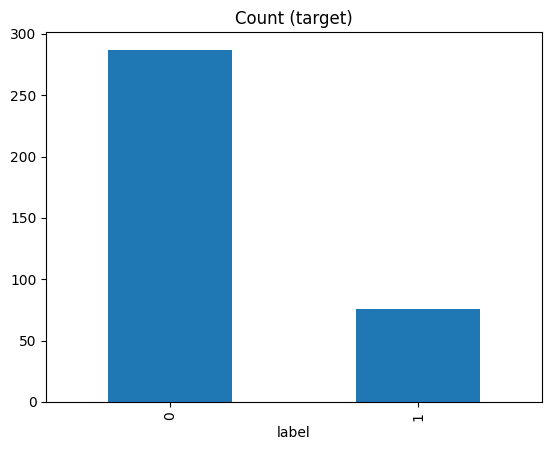

In [6]:
target_count = df.label.value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 2), ': 1')
target_count.plot(kind='bar', title='Count (target)')

In [6]:
X = df_enchanced.drop(columns=["label"])
y = df_enchanced["label"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (363, 33)
Target shape: (363,)


In [9]:
y = (y > 0).astype(int)

In [10]:
n_negative = (y == 0).sum()
n_positive = (y == 1).sum()

print(f"negative: {n_negative} | positive: {n_positive}")

negative: 287 | positive: 76


### Model Training

In [12]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from xgboost import XGBClassifier, cv
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


#### Split dataset into training and testing sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, 
  test_size=0.2, random_state=1  
)

In [14]:
X_train

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,QRS_amplitude_mean,QRS_amplitude_std,ST_QT_ratio,ST_V1_slope,...,QRS_ST_ratio,QRS_ST_V1_ratio,QRS_ST_V2_ratio,QRS_CV,QRS_normalized,ST_QT_ratio_check,ST_V1_asymmetry,ST_V2_asymmetry,ST_asymmetry_mean,brugada_score
197,0.536404,0.232056,0.732112,0.195676,0.107639,0.436826,6.004777,0.400010,0.005944,0.424698,...,12.811061,10.989636,8.091473,0.066615,0.794720,0.005944,0.424698,0.263674,0.344186,0.496867
354,0.521846,1.004906,1.566625,0.364358,0.954005,0.347815,3.459092,0.210119,0.006854,1.889467,...,3.377496,6.503929,2.193985,0.060744,0.457804,0.006854,1.889467,0.231100,1.060284,0.898785
208,0.406377,1.064849,1.051572,0.722686,0.715920,1.311965,5.137687,0.970461,0.004630,2.557416,...,6.993636,12.339024,4.839695,0.188891,0.679963,0.004630,2.557416,0.680769,1.619093,0.907066
39,0.597439,1.326325,0.460351,0.302707,0.116720,0.578360,3.278605,0.195012,0.006754,2.183470,...,8.165822,5.397423,6.970552,0.059480,0.433917,0.006754,2.183470,0.643577,1.413524,0.802466
296,1.034157,0.147997,0.722605,0.190281,0.193230,0.196478,5.542810,0.477054,0.010023,0.141738,...,8.398234,5.308409,7.565890,0.086067,0.733580,0.010023,0.141738,0.259732,0.200735,0.525842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,1.491463,0.828042,1.579796,0.590068,0.590749,0.818972,3.461146,0.130522,0.019121,0.551490,...,2.812409,2.305182,2.177100,0.037710,0.458076,0.019121,0.551490,0.371160,0.461325,0.822530
255,1.059120,0.274982,0.887470,0.376430,0.412665,0.356499,6.097084,0.739803,0.007007,0.257204,...,7.655631,5.702901,6.793633,0.121337,0.806937,0.007007,0.257204,0.419434,0.338319,0.567368
72,-0.276851,0.534345,-0.122461,0.764393,0.603191,0.257899,4.077778,0.205020,-0.003934,1.862798,...,52.306261,-15.281111,-36.259404,0.050277,0.539686,-0.003934,1.862798,5.770689,3.816744,1.963175
235,0.869595,0.451081,0.882643,0.425535,0.853668,0.534910,5.446340,0.401978,0.009839,0.512828,...,6.198636,6.191871,6.101364,0.073807,0.720812,0.009839,0.512828,0.476714,0.494771,0.515012


In [15]:
X_test

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,QRS_amplitude_mean,QRS_amplitude_std,ST_QT_ratio,ST_V1_slope,...,QRS_ST_ratio,QRS_ST_V1_ratio,QRS_ST_V2_ratio,QRS_CV,QRS_normalized,ST_QT_ratio_check,ST_V1_asymmetry,ST_V2_asymmetry,ST_asymmetry_mean,brugada_score
277,0.694333,0.857790,1.033524,0.599035,0.413635,0.457755,6.047873,0.507930,0.006017,1.217875,...,8.355369,8.586666,5.795623,0.083985,0.800424,0.006017,1.217875,0.574050,0.895962,0.711835
304,0.265701,1.260354,0.202728,0.837672,-0.476564,1.047809,3.821758,0.555442,0.003246,4.571455,...,524.375635,13.861978,17.965473,0.145337,0.505802,0.003246,4.571455,3.937761,4.254608,43.275934
93,0.068464,0.590799,0.665385,0.619975,0.280239,0.404681,5.581243,1.105205,0.000663,7.529570,...,16.036700,71.131411,8.263788,0.198021,0.738666,0.000663,7.529570,0.917957,4.223764,0.790018
132,-0.251218,0.263472,-0.314786,0.171790,-0.499156,0.222576,5.055615,0.265664,-0.004324,1.008627,...,-14.651693,-20.958692,-16.587440,0.052548,0.669101,-0.004324,1.008627,0.528933,0.768780,-0.284779
175,1.718126,0.760384,0.986092,0.281884,0.475490,0.506923,3.983098,0.866277,0.022687,0.440005,...,3.722861,2.304866,3.998727,0.217488,0.527155,0.022687,0.440005,0.282990,0.361498,0.905251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,0.834393,0.764280,1.054216,0.761669,0.829975,0.417515,5.696900,0.542461,0.009255,0.905123,...,6.218001,6.746740,5.353140,0.095220,0.753973,0.009255,0.905123,0.715708,0.810416,0.655792
303,0.726369,0.697422,0.554172,0.588416,0.455130,0.389084,5.085717,1.378527,0.008529,0.947110,...,8.640996,6.906480,9.014484,0.271059,0.673085,0.008529,0.947110,1.042974,0.995042,0.592349
223,0.965157,0.132263,1.066614,0.377857,0.619817,0.328055,7.149204,0.378872,0.009280,0.135633,...,7.998100,7.331333,6.640453,0.052995,0.946183,0.009280,0.135633,0.350968,0.243301,0.530561
227,-0.066553,0.659117,0.042472,0.866881,0.096837,0.417159,3.628963,0.366926,-0.000795,8.609916,...,105.949426,-64.168986,69.160250,0.101110,0.480286,-0.000795,8.609916,16.520897,12.565407,5.701038


In [16]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 79.45%


In [17]:
model = XGBClassifier()
model.fit(X_train[['st_V1_mean']], y_train)
y_pred = model.predict(X_test[['st_V1_mean']])

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

KeyError: "None of [Index(['st_V1_mean'], dtype='object')] are in the [columns]"

In [16]:
conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print('Confusion matrix:\n', conf_mat)

Confusion matrix:
 [[49 10]
 [12  2]]


#### Train XGBoost Classifier without SMOTE

In [18]:
skf = StratifiedKFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

In [19]:
xgb1_pipe = Pipeline([
  ("scaler", StandardScaler()),
  ("xgb", XGBClassifier(
    n_estimators=100,
    max_depth=3, 
    learning_rate=0.05,
    subsample=1,
    colsample_bytree=0.7,
    gamma=1.0,
    scale_pos_weight=n_negative / n_positive,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
  ))
])

#### Cross Validation

In [20]:
y_cv_pred = cross_val_predict(xgb1_pipe, X_train, y_train, cv=skf, method='predict')

In [21]:
print(confusion_matrix(y_train, y_cv_pred))
print(classification_report(y_train, y_cv_pred))

[[201  27]
 [ 25  37]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       228
           1       0.58      0.60      0.59        62

    accuracy                           0.82       290
   macro avg       0.73      0.74      0.74       290
weighted avg       0.82      0.82      0.82       290



In [22]:
xgb1_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


#### Predicting on the train set

In [23]:
y_pred = xgb1_pipe.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[47 12]
 [11  3]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        59
           1       0.20      0.21      0.21        14

    accuracy                           0.68        73
   macro avg       0.51      0.51      0.51        73
weighted avg       0.69      0.68      0.69        73



#### Predict on test set

In [24]:
y_test_pred = xgb1_pipe.predict(X_test)
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

[[47 12]
 [11  3]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        59
           1       0.20      0.21      0.21        14

    accuracy                           0.68        73
   macro avg       0.51      0.51      0.51        73
weighted avg       0.69      0.68      0.69        73



#### Check accuracy score

In [24]:
# compute and print accuracy score
print('XGBoost model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_test_pred)))

XGBoost model accuracy score: 0.8082


#### Train XGBoost Classifier with SMOTE

In [25]:
from sklearn.feature_selection import SelectKBest, f_classif

In [26]:
xgb_clf_smote = XGBClassifier(
  n_estimators=100,
  max_depth=3, 
  learning_rate=0.05,
  subsample=0.4,
  colsample_bytree=0.4,
  scale_pos_weight=1,
  eval_metric="logloss",
  random_state=42,
  n_jobs=-1,
)

In [27]:
xgb2_pipe = Pipeline([
  ("smote", SMOTE(random_state=42)),
  ("scaler", StandardScaler()),
  # ('selector', SelectKBest(f_classif, k=20)),
  ("xgb", xgb_clf_smote)
])

#### Cross Validation

In [28]:
y_cv_pred = cross_val_predict(
  xgb2_pipe,
  X, y,
  cv=skf,
  method='predict'
)

In [29]:
cm = confusion_matrix(y, y_cv_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  [[TN={tn:3d}  FP={fp:3d}]")
print(f"   [FN={fn:3d}  TP={tp:3d}]]")

print(f"\nMetrics:")
print(f"  Sensitivity: {tp/(tp+fn):.4f}")
print(f"  Specificity: {tn/(tn+fp):.4f}")
print(f"  Precision: {tp/(tp+fp):.4f}")

print(f"\nClassification Report:")
print(classification_report(y, y_cv_pred, target_names=['Normal', 'Brugada']))


Confusion Matrix:
  [[TN=237  FP= 50]
   [FN= 29  TP= 47]]

Metrics:
  Sensitivity: 0.6184
  Specificity: 0.8258
  Precision: 0.4845

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.83      0.86       287
     Brugada       0.48      0.62      0.54        76

    accuracy                           0.78       363
   macro avg       0.69      0.72      0.70       363
weighted avg       0.81      0.78      0.79       363



In [30]:
xgb2_pipe.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'


#### Predict on train set

In [31]:
y_train_pred = xgb2_pipe.predict(X_train)

In [32]:
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

[[210  18]
 [  7  55]]
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       228
           1       0.75      0.89      0.81        62

    accuracy                           0.91       290
   macro avg       0.86      0.90      0.88       290
weighted avg       0.92      0.91      0.92       290



#### Predict on test set

In [33]:
y_test_pred = xgb2_pipe.predict(X_test)

In [34]:
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

[[46 13]
 [10  4]]
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        59
           1       0.24      0.29      0.26        14

    accuracy                           0.68        73
   macro avg       0.53      0.53      0.53        73
weighted avg       0.71      0.68      0.70        73



In [35]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm.ravel())

[44 15  9  5]


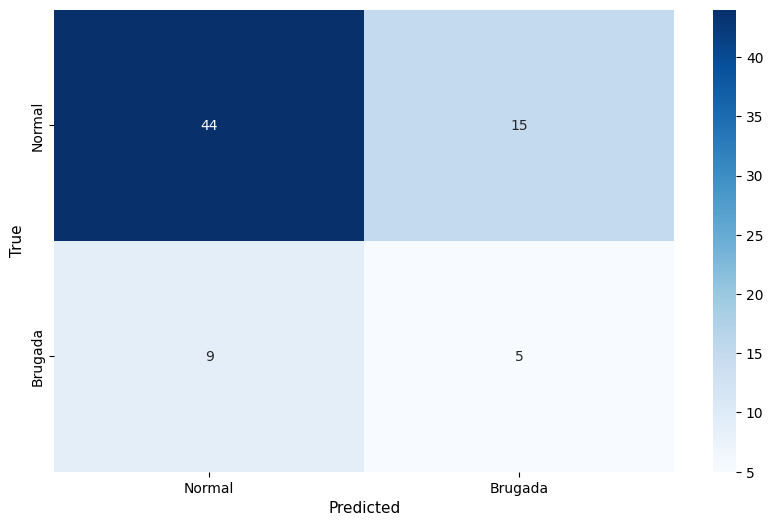

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(
  cm, 
  annot=True, 
  fmt="d", 
  cmap="Blues", 
  xticklabels=["Normal", "Brugada"],
  yticklabels=["Normal", "Brugada"], 
)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.show()

#### Feature Importance

In [37]:
feature_names = df.drop(columns='label', axis=1).columns

In [38]:
xgb_model = xgb2_pipe.named_steps['xgb']
feature_importances = xgb_model.feature_importances_

In [39]:
df_importance = pd.DataFrame({
  'Feature': np.array(feature_names),
  'Importance': feature_importances
}).sort_values('Importance', ascending=False)

In [40]:
df_importance.head(20)

,Feature,Importance
40,st_V2_std,0.060616
37,st_V1_std,0.058972
24,V3_mean,0.058902
41,st_V2_rms,0.057664
44,st_V3_rms,0.054857
42,st_V3_mean,0.054215
38,st_V1_rms,0.053809
30,V5_mean,0.053501
18,V1_mean,0.052745
3,II_mean,0.051215


In [41]:
print("\nTop 10 Features:")
for idx, row in df_importance.head(10).iterrows():
    print(f"  {row['Feature']:<20} {row['Importance']:.4f}")


Top 10 Features:
  st_V2_std            0.0606
  st_V1_std            0.0590
  V3_mean              0.0589
  st_V2_rms            0.0577
  st_V3_rms            0.0549
  st_V3_mean           0.0542
  st_V1_rms            0.0538
  V5_mean              0.0535
  V1_mean              0.0527
  II_mean              0.0512


#### Parameter search 

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
# Comprehensive parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1.0]
}

small_param_grid = {
    'n_estimators': [100, 200, 300],      # Tree count
    'max_depth': [3, 4, 5, 6],            # Tree depth
    'learning_rate': [0.01, 0.02, 0.05], # Learning speed
    'subsample': [0.4, 0.6, 0.8],         # Row sampling
    'colsample_bytree': [0.4, 0.6, 0.8], # Feature sampling
}

In [ ]:
# Initialize XGBoost with GPU parameters
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    tree_method='gpu_hist',
    predictor='gpu_predictor',
    use_label_encoder=False,
    eval_metric='auc'
)

In [45]:
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=small_param_grid,
    scoring='roc_auc',          # Metric to optimize
    cv=5,                       # 5-fold CV (better than cv=2)
    verbose=2,
    n_jobs=-1,                  # Parallel processing
    return_train_score=True,    # Get train scores too
)

# 3. Fit on training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.4; total time=   2.5s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   2.7s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.1s


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.1s


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   3.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.4; total time=   3.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.6; total time=   3.6s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.4; total time=   3.5s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.4; total time=   3.5s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.4; total time=   3.7s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=3, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.4; total time=   0.4s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=4, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.4; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estima

/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=300, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.4; total time=   0.1s


/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:27:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/giant/Desktop/project/DataScie-Physionet/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [1

[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.4; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.4; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.4, learning_rate=0.01, max_depth=5, n_estima

KeyboardInterrupt: 

In [ ]:
# Extract best results
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        61
           1       0.33      0.17      0.22        12

    accuracy                           0.81        73
   macro avg       0.59      0.55      0.56        73
weighted avg       0.77      0.81      0.78        73



In [ ]:
print(f"Best parameters: {best_params}")
print(f"Best cross-validation AUC: {best_score:.4f}")
# Test set validation
test_predictions = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_predictions)
print(f"Test set AUC: {test_auc:.4f}")

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.4}
Best cross-validation AUC: 0.6892
Test set AUC: 0.7281


In [ ]:
print(test_predictions)

[0.10308675 0.03582133 0.2835953  0.15288134 0.5147509  0.06158643
 0.8253887  0.04802968 0.07896389 0.05642542 0.51936525 0.05837304
 0.33718997 0.13357979 0.43854728 0.15442233 0.03273537 0.06865928
 0.1555416  0.45317832 0.12648326 0.1223608  0.36968675 0.16475017
 0.08436721 0.3636878  0.2754944  0.06620298 0.6361737  0.14307529
 0.11768384 0.10388839 0.17378941 0.02282762 0.06221082 0.04343478
 0.06080102 0.48046282 0.22960225 0.37416616 0.04856382 0.04149216
 0.17218544 0.46034878 0.06111178 0.52195793 0.23134728 0.03228637
 0.1151619  0.03954435 0.17928164 0.30158255 0.03803651 0.48641184
 0.13680722 0.10853823 0.1920961  0.2081911  0.23998262 0.16129202
 0.6513571  0.13011342 0.22981934 0.03774134 0.03615649 0.04644287
 0.06156693 0.07415823 0.33220407 0.04295328 0.24147306 0.38641003
 0.3649615 ]


In [ ]:
print(confusion_matrix(y_test, test_predictions))
print(classification_report(y_test, test_predictions))

ValueError: Classification metrics can't handle a mix of binary and continuous targets